In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
tickers = [
    "KO", "PEP",
    "XOM", "CVX",
    "JPM", "BAC",
    "MSFT", "AAPL",
    "GOOGL", "META",
    "COST", "WMT",
    "V", "MA",
    "HD", "LOW"
]

data = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

prices = data["Close"]

prices.head()

[*********************100%***********************]  16 of 16 completed


Ticker,AAPL,BAC,COST,CVX,GOOGL,HD,JPM,KO,LOW,MA,META,MSFT,PEP,V,WMT,XOM
Date,,,,,,,,,,,,,,,,
2021-01-04,125.632477,26.193615,358.108032,66.632011,85.492981,228.691528,109.000511,44.792778,144.040390,340.009399,266.598846,207.565399,119.999924,208.751572,45.345749,33.251335
2021-01-05,127.185768,26.394230,353.953644,68.433319,86.182411,230.537201,109.593620,44.300365,144.525421,336.072388,268.611176,207.765625,120.357613,205.636017,45.104366,34.853794
2021-01-06,122.904510,28.042782,348.565308,70.635773,85.332016,231.854340,114.739693,42.891041,146.456314,336.198151,261.017792,202.378372,118.885338,203.824203,45.385979,35.743183
2021-01-07,127.098404,28.662075,346.587097,70.966110,87.880760,230.719223,118.507652,42.415604,147.031128,338.861633,266.400574,208.137512,118.502724,204.964981,45.382881,36.023609
2021-01-08,128.195419,28.374239,348.489960,71.642593,89.044174,233.171432,118.638496,43.366474,148.234589,342.726288,265.240784,209.405594,119.925056,206.537125,45.376698,36.424217


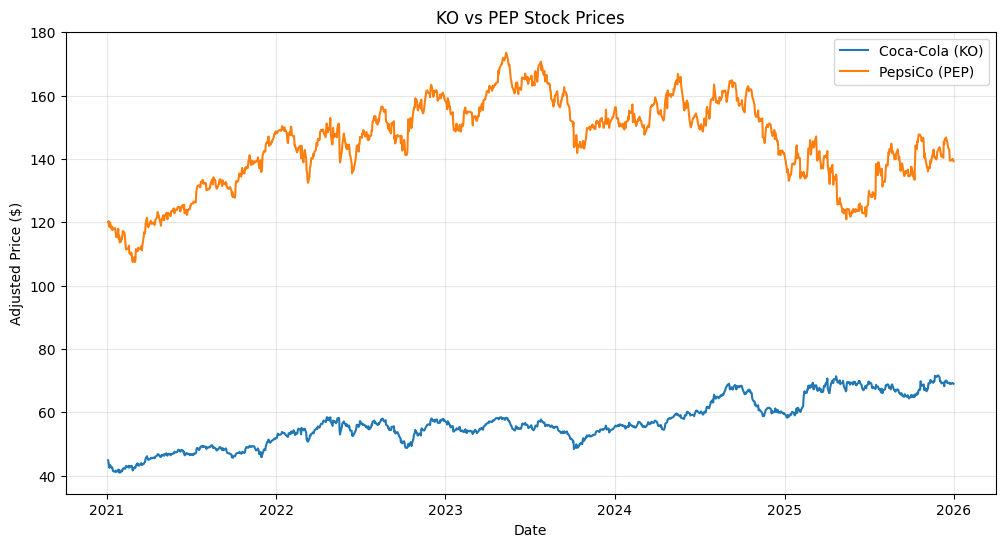

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(prices["KO"], label="Coca-Cola (KO)")
plt.plot(prices["PEP"], label="PepsiCo (PEP)")

plt.title("KO vs PEP Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Price ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [6]:
ko_pep_corr = prices[["KO", "PEP"]].corr()

ko_pep_corr

Ticker,KO,PEP
Ticker,,
KO,1.000000,0.281275
PEP,0.281275,1.000000


In [7]:
returns = prices.pct_change()

returns[["KO", "PEP"]].corr()

Ticker,KO,PEP
Ticker,,
KO,1.000000,0.688746
PEP,0.688746,1.000000


In [8]:
from statsmodels.tsa.stattools import coint

ko = prices["KO"]
pep = prices["PEP"]

score, p_value, _ = coint(ko, pep)

print("Cointegration test statistic:", score)
print("p-value:", p_value)

Cointegration test statistic: -1.0288034208461745
p-value: 0.8972467949902478


In [9]:
from statsmodels.tsa.stattools import coint
import itertools

results = []

for stock1, stock2 in itertools.combinations(prices.columns, 2):

    pair_data = prices[[stock1, stock2]].dropna()

    score, p_value, _ = coint(
        pair_data[stock1],
        pair_data[stock2]
    )

    results.append({
        "Stock 1": stock1,
        "Stock 2": stock2,
        "Test Statistic": score,
        "P-Value": p_value
    })

cointegration_results = pd.DataFrame(results)

cointegration_results = cointegration_results.sort_values("P-Value")

cointegration_results.head(10)

,Stock 1,Stock 2,Test Statistic,P-Value
82,JPM,WMT,-4.049331,0.006100
103,MA,WMT,-4.002614,0.007120
102,MA,V,-3.894915,0.010081
99,MA,META,-3.798318,0.013626
117,V,WMT,-3.798148,0.013633
93,LOW,META,-3.703796,0.018121
94,LOW,MSFT,-3.663552,0.020398
69,HD,META,-3.652925,0.021039
92,LOW,MA,-3.531921,0.029669
97,LOW,WMT,-3.489497,0.033338


In [10]:
cointegration_results.head(10)

,Stock 1,Stock 2,Test Statistic,P-Value
82,JPM,WMT,-4.049331,0.006100
103,MA,WMT,-4.002614,0.007120
102,MA,V,-3.894915,0.010081
99,MA,META,-3.798318,0.013626
117,V,WMT,-3.798148,0.013633
93,LOW,META,-3.703796,0.018121
94,LOW,MSFT,-3.663552,0.020398
69,HD,META,-3.652925,0.021039
92,LOW,MA,-3.531921,0.029669
97,LOW,WMT,-3.489497,0.033338


In [11]:
for _, row in cointegration_results.head(10).iterrows():
    print(
        f"{row['Stock 1']} / {row['Stock 2']} "
        f"→ p-value = {row['P-Value']:.4f}"
    )

JPM / WMT → p-value = 0.0061
MA / WMT → p-value = 0.0071
MA / V → p-value = 0.0101
MA / META → p-value = 0.0136
V / WMT → p-value = 0.0136
LOW / META → p-value = 0.0181
LOW / MSFT → p-value = 0.0204
HD / META → p-value = 0.0210
LOW / MA → p-value = 0.0297
LOW / WMT → p-value = 0.0333


In [12]:
ma_v_returns_corr = returns[["MA", "V"]].corr()

ma_v_returns_corr

Ticker,MA,V
Ticker,,
MA,1.000000,0.882816
V,0.882816,1.000000


In [13]:
top_pairs = cointegration_results.head(10).copy()

top_pairs["Return Correlation"] = [
    returns[[row["Stock 1"], row["Stock 2"]]].corr().iloc[0, 1]
    for _, row in top_pairs.iterrows()
]

top_pairs[[
    "Stock 1",
    "Stock 2",
    "P-Value",
    "Return Correlation"
]]

,Stock 1,Stock 2,P-Value,Return Correlation
82,JPM,WMT,0.006100,0.227948
103,MA,WMT,0.007120,0.265905
102,MA,V,0.010081,0.882816
99,MA,META,0.013626,0.397810
117,V,WMT,0.013633,0.253549
93,LOW,META,0.018121,0.330823
94,LOW,MSFT,0.020398,0.369459
69,HD,META,0.021039,0.341880
92,LOW,MA,0.029669,0.404920
97,LOW,WMT,0.033338,0.308505


In [14]:
import statsmodels.api as sm

ma = prices["MA"]
v = prices["V"]

X = sm.add_constant(v)

model = sm.OLS(ma, X).fit()

beta = model.params["V"]
alpha = model.params["const"]

print(f"Hedge ratio (β): {beta:.4f}")
print(f"Intercept (α): {alpha:.4f}")

Hedge ratio (β): 1.6275
Intercept (α): 6.2637


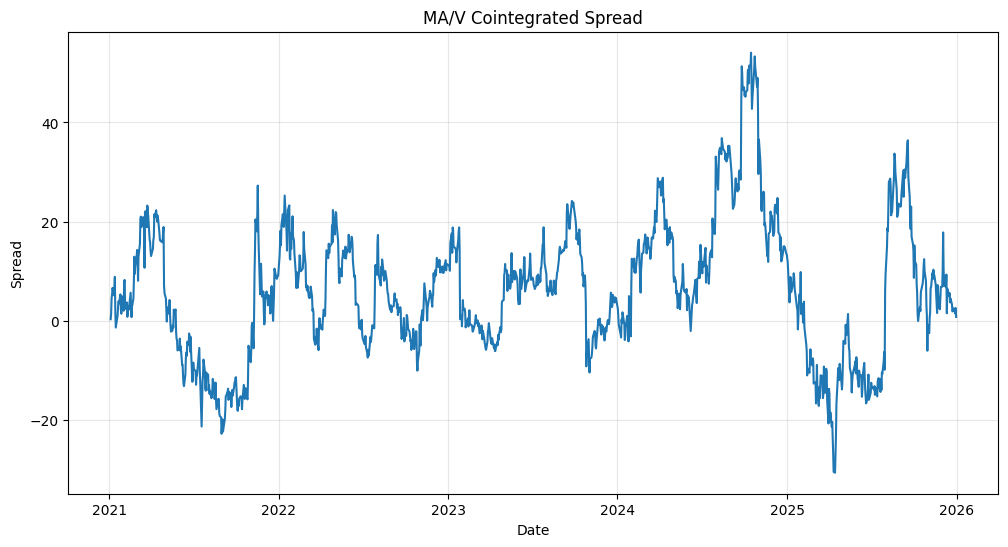

In [15]:
spread = ma - beta * v

plt.figure(figsize=(12, 6))
plt.plot(spread)

plt.title("MA/V Cointegrated Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(alpha=0.3)

plt.show()

In [16]:
spread_mean = spread.mean()
spread_std = spread.std()

z_score = (spread - spread_mean) / spread_std

print(f"Mean spread: {spread_mean:.4f}")
print(f"Spread standard deviation: {spread_std:.4f}")

Mean spread: 6.2637
Spread standard deviation: 13.7299


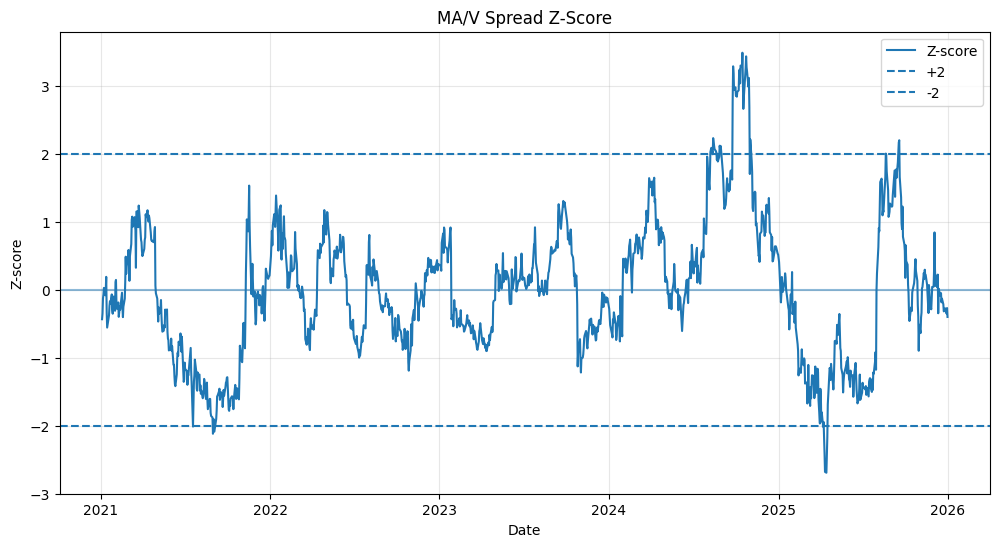

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(z_score, label="Z-score")
plt.axhline(2, linestyle="--", label="+2")
plt.axhline(0, linestyle="-", alpha=0.5)
plt.axhline(-2, linestyle="--", label="-2")

plt.title("MA/V Spread Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [18]:
signals = pd.Series(0, index=z_score.index)

# Long spread
signals[z_score < -2] = 1

# Short spread
signals[z_score > 2] = -1

# Exit when the spread crosses zero
signals[z_score.abs() < 0.5] = 0

signals = signals.ffill().fillna(0)

signals.value_counts()

,count
0,1200
-1,44
1,11


In [19]:
ma_returns = prices["MA"].pct_change()
v_returns = prices["V"].pct_change()

spread_returns = ma_returns - beta * v_returns

strategy_returns = signals.shift(1) * spread_returns

strategy_returns = strategy_returns.fillna(0)

strategy_returns.head()

,0
Date,
2021-01-04,0.0
2021-01-05,0.0
2021-01-06,0.0
2021-01-07,-0.0
2021-01-08,-0.0


In [20]:
strategy_returns[strategy_returns != 0].head(10)

,0
Date,
2021-07-20,0.008961
2021-09-01,0.002401
2021-09-02,0.018294
2021-09-07,0.004781
2024-08-08,0.008240
2024-08-09,0.000190
2024-08-12,0.003201
2024-08-14,0.004577
2024-08-15,0.016693


In [21]:
print("Non-zero strategy return days:", (strategy_returns != 0).sum())
print("Total strategy return:", strategy_returns.sum())

Non-zero strategy return days: 55
Total strategy return: 0.23295409022799834


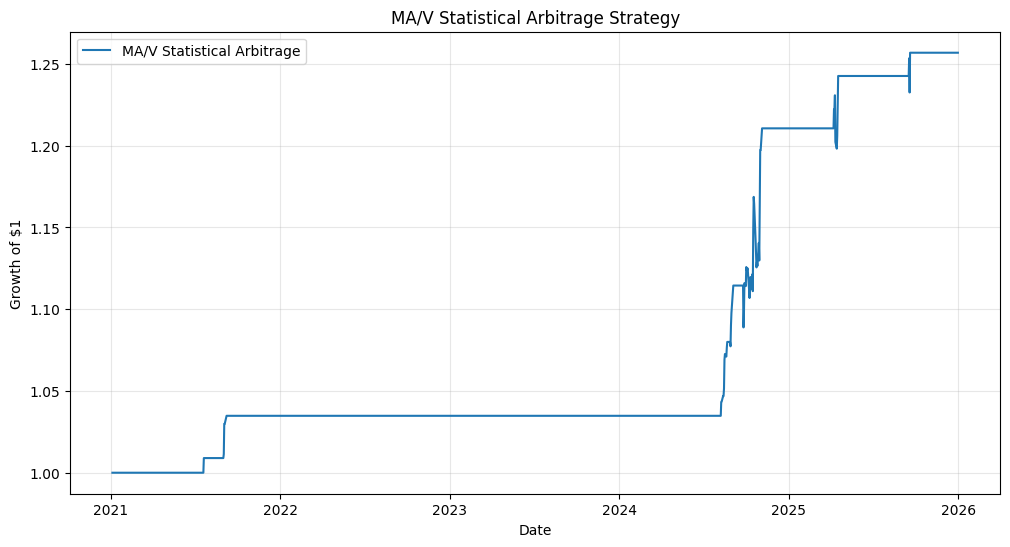

In [22]:
cumulative_strategy = (1 + strategy_returns).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(cumulative_strategy, label="MA/V Statistical Arbitrage")

plt.title("MA/V Statistical Arbitrage Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
# Remove the initial zero days for some statistics
active_returns = strategy_returns[strategy_returns != 0]

# Annualised return
total_return = cumulative_strategy.iloc[-1] - 1
years = (strategy_returns.index[-1] - strategy_returns.index[0]).days / 365.25
annualised_return = (1 + total_return) ** (1 / years) - 1

# Annualised volatility
annualised_vol = strategy_returns.std() * np.sqrt(252)

# Sharpe ratio
sharpe = (
    strategy_returns.mean() / strategy_returns.std()
) * np.sqrt(252)

# Maximum drawdown
running_max = cumulative_strategy.cummax()
drawdown = cumulative_strategy / running_max - 1
max_drawdown = drawdown.min()

print(f"Total return: {total_return:.2%}")
print(f"Annualised return: {annualised_return:.2%}")
print(f"Annualised volatility: {annualised_vol:.2%}")
print(f"Sharpe ratio: {sharpe:.2f}")
print(f"Maximum drawdown: {max_drawdown:.2%}")

Total return: 25.69%
Annualised return: 4.69%
Annualised volatility: 4.17%
Sharpe ratio: 1.12
Maximum drawdown: -3.69%


In [24]:
# Split the data into training and out-of-sample periods

train = prices.loc["2021-01-01":"2024-12-31"]
test = prices.loc["2025-01-01":"2025-12-31"]

print("Training period:", train.index.min().date(), "to", train.index.max().date())
print("Test period:", test.index.min().date(), "to", test.index.max().date())

Training period: 2021-01-04 to 2024-12-31
Test period: 2025-01-02 to 2025-12-31


In [25]:
import statsmodels.api as sm

ma_train = train["MA"]
v_train = train["V"]

X_train = sm.add_constant(v_train)

model_train = sm.OLS(ma_train, X_train).fit()

beta_train = model_train.params["V"]
alpha_train = model_train.params["const"]

print(f"Training hedge ratio (β): {beta_train:.4f}")
print(f"Training intercept (α): {alpha_train:.4f}")

Training hedge ratio (β): 1.8028
Training intercept (α): -32.5358


In [26]:
spread_train = ma_train - beta_train * v_train

train_mean = spread_train.mean()
train_std = spread_train.std()

print(f"Training spread mean: {train_mean:.4f}")
print(f"Training spread std: {train_std:.4f}")

Training spread mean: -32.5358
Training spread std: 11.9196


In [27]:
ma_test = test["MA"]
v_test = test["V"]

spread_test = ma_test - beta_train * v_test

z_test = (spread_test - train_mean) / train_std

print(z_test.head())

Date
2025-01-02   -0.841073
2025-01-03   -1.003537
2025-01-06   -1.507147
2025-01-07   -1.346632
2025-01-08   -1.070416
dtype: float64


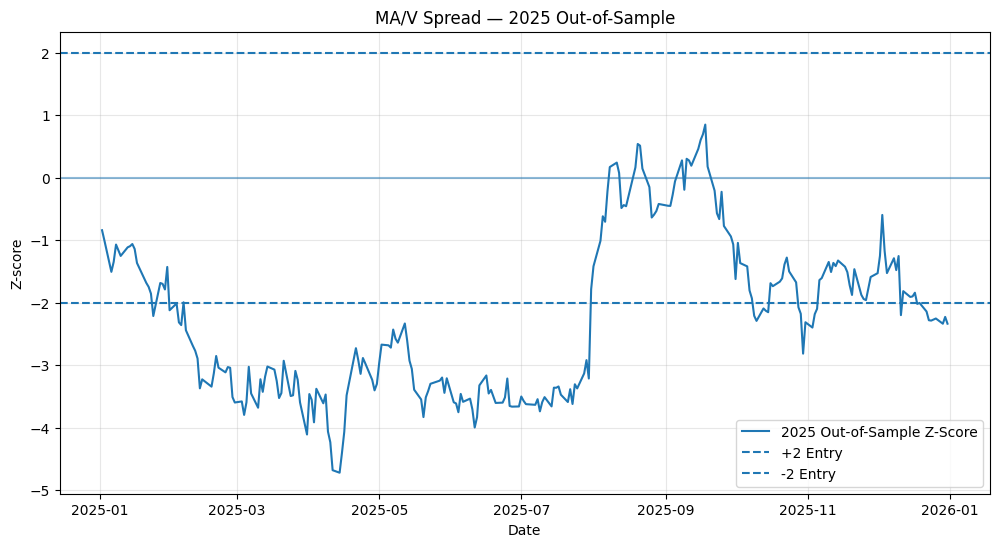

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(z_test, label="2025 Out-of-Sample Z-Score")
plt.axhline(2, linestyle="--", label="+2 Entry")
plt.axhline(0, linestyle="-", alpha=0.5)
plt.axhline(-2, linestyle="--", label="-2 Entry")

plt.title("MA/V Spread — 2025 Out-of-Sample")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [29]:
# Generate out-of-sample trading signals

test_signals = pd.Series(0, index=z_test.index)

# Enter long spread when z-score is below -2
test_signals[z_test < -2] = 1

# Enter short spread when z-score is above +2
test_signals[z_test > 2] = -1

# Exit when z-score returns close to the mean
test_signals[z_test.abs() < 0.5] = 0

# Hold the existing position until an exit signal occurs
test_signals = test_signals.replace(0, np.nan).ffill().fillna(0)

print("Long-spread days:", (test_signals == 1).sum())
print("Short-spread days:", (test_signals == -1).sum())
print("Flat days:", (test_signals == 0).sum())

Long-spread days: 236
Short-spread days: 0
Flat days: 14


In [30]:
ma_test_returns = ma_test.pct_change()
v_test_returns = v_test.pct_change()

test_spread_returns = ma_test_returns - beta_train * v_test_returns

test_strategy_returns = (
    test_signals.shift(1) * test_spread_returns
).fillna(0)

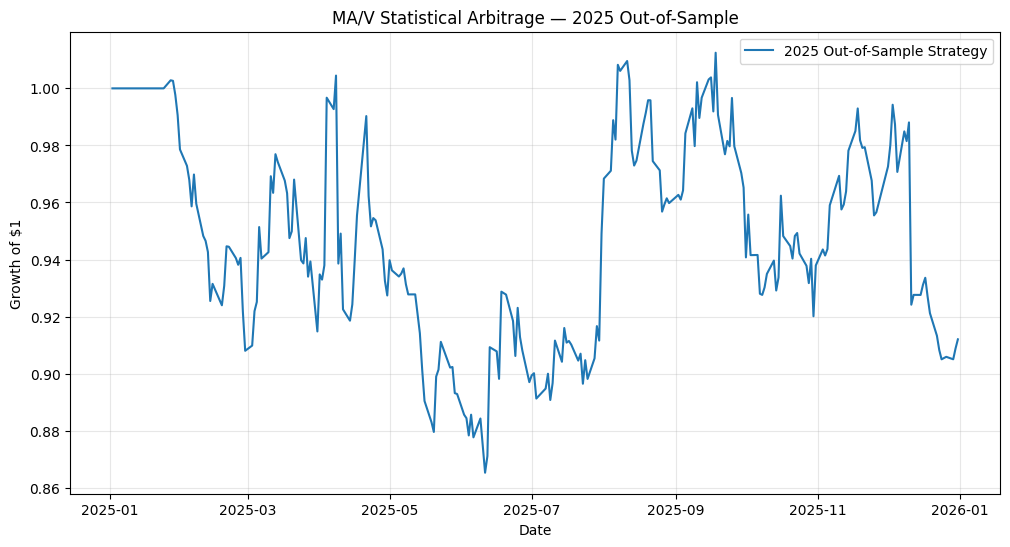

In [31]:
test_equity = (1 + test_strategy_returns).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(test_equity, label="2025 Out-of-Sample Strategy")

plt.title("MA/V Statistical Arbitrage — 2025 Out-of-Sample")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [32]:
# Capital-normalised portfolio weights
w_ma = 1 / (1 + abs(beta_train))
w_v = -abs(beta_train) / (1 + abs(beta_train))

print(f"MA weight: {w_ma:.4f}")
print(f"V weight: {w_v:.4f}")

# Daily return of the market-neutral portfolio
portfolio_returns = (
    test_signals.shift(1) *
    (w_ma * ma_test_returns + w_v * v_test_returns)
).fillna(0)

portfolio_returns.head()

MA weight: 0.3568
V weight: -0.6432


,0
Date,
2025-01-02,0.0
2025-01-03,-0.0
2025-01-06,-0.0
2025-01-07,0.0
2025-01-08,0.0


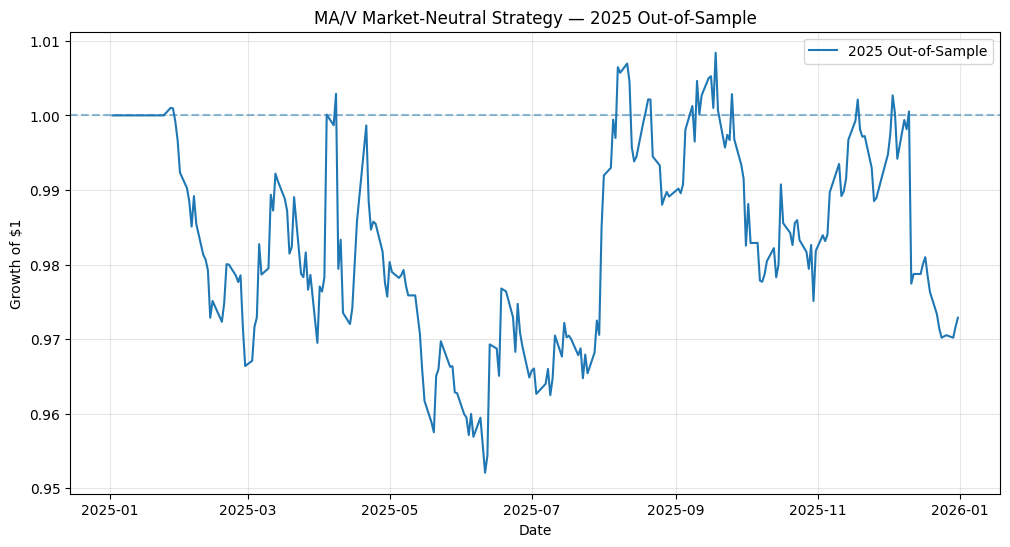

In [33]:
portfolio_equity = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_equity,
    label="2025 Out-of-Sample"
)

plt.axhline(1, linestyle="--", alpha=0.5)

plt.title("MA/V Market-Neutral Strategy — 2025 Out-of-Sample")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [34]:
total_return = portfolio_equity.iloc[-1] - 1
annualised_vol = portfolio_returns.std() * np.sqrt(252)

sharpe = (
    portfolio_returns.mean() /
    portfolio_returns.std()
) * np.sqrt(252)

running_max = portfolio_equity.cummax()
drawdown = portfolio_equity / running_max - 1
max_drawdown = drawdown.min()

print(f"2025 Total Return: {total_return:.2%}")
print(f"2025 Annualised Volatility: {annualised_vol:.2%}")
print(f"2025 Sharpe Ratio: {sharpe:.2f}")
print(f"2025 Maximum Drawdown: {max_drawdown:.2%}")

2025 Total Return: -2.71%
2025 Annualised Volatility: 7.74%
2025 Sharpe Ratio: -0.32
2025 Maximum Drawdown: -5.07%


The strategy appeared profitable in the exploratory full-sample backtest, but performance deteriorated when parameters were estimated only from the 2021–2024 training period and evaluated on unseen 2025 data.

In [35]:
# Count position changes
position_changes = test_signals.diff().fillna(0)

entries = (position_changes != 0) & (test_signals != 0)
exits = (position_changes != 0) & (test_signals == 0)

print("Entries:", entries.sum())
print("Exits:", exits.sum())
print("Total position changes:", (position_changes != 0).sum())

Entries: 1
Exits: 0
Total position changes: 1


In [36]:
# Show the dates and directions of every position change
trade_log = pd.DataFrame({
    "Signal": test_signals,
    "Z-Score": z_test
})

trade_log = trade_log[test_signals.diff().fillna(test_signals) != 0]

trade_log

,Signal,Z-Score
Date,,
2025-01-24,1.0,-2.213904


In [37]:
# Corrected stateful trading signal

test_signals = pd.Series(0.0, index=z_test.index)

position = 0

for date in z_test.index:
    z = z_test.loc[date]

    if position == 0:
        if z < -2:
            position = 1
        elif z > 2:
            position = -1

    elif position == 1:
        if z > -0.5:
            position = 0

    elif position == -1:
        if z < 0.5:
            position = 0

    test_signals.loc[date] = position

print("Long-spread days:", (test_signals == 1).sum())
print("Short-spread days:", (test_signals == -1).sum())
print("Flat days:", (test_signals == 0).sum())

Long-spread days: 192
Short-spread days: 0
Flat days: 58


In [38]:
position_changes = test_signals.diff().fillna(test_signals)

trade_log = pd.DataFrame({
    "Signal": test_signals,
    "Z-Score": z_test
})

trade_log = trade_log[position_changes != 0]

trade_log

,Signal,Z-Score
Date,,
2025-01-24,1.0,-2.213904
2025-08-07,0.0,-0.219475
2025-10-09,1.0,-2.210408


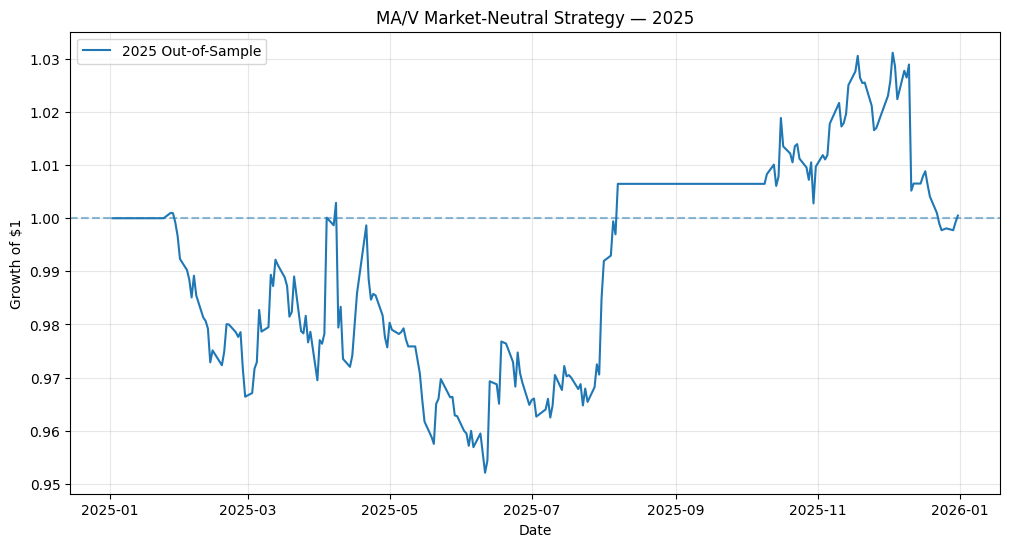

In [39]:
# Recalculate the market-neutral portfolio using corrected signals

portfolio_returns = (
    test_signals.shift(1) *
    (w_ma * ma_test_returns + w_v * v_test_returns)
).fillna(0)

portfolio_equity = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_equity,
    label="2025 Out-of-Sample"
)

plt.axhline(1, linestyle="--", alpha=0.5)

plt.title("MA/V Market-Neutral Strategy — 2025")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [40]:
total_return = portfolio_equity.iloc[-1] - 1
annualised_vol = portfolio_returns.std() * np.sqrt(252)

sharpe = (
    portfolio_returns.mean() /
    portfolio_returns.std()
) * np.sqrt(252)

running_max = portfolio_equity.cummax()
drawdown = portfolio_equity / running_max - 1
max_drawdown = drawdown.min()

print(f"2025 Total Return: {total_return:.2%}")
print(f"2025 Annualised Volatility: {annualised_vol:.2%}")
print(f"2025 Sharpe Ratio: {sharpe:.2f}")
print(f"2025 Maximum Drawdown: {max_drawdown:.2%}")

2025 Total Return: 0.05%
2025 Annualised Volatility: 7.19%
2025 Sharpe Ratio: 0.04
2025 Maximum Drawdown: -5.07%


In [41]:
# Transaction cost assumption
cost_rate = 0.0005  # 5 basis points = 0.05%

print(f"Transaction cost per unit of turnover: {cost_rate:.2%}")

Transaction cost per unit of turnover: 0.05%


In [42]:
# Change in position = trading turnover
turnover = test_signals.diff().abs()

# Account for entering the initial position
turnover.iloc[0] = abs(test_signals.iloc[0])

print("Total signal turnover:", turnover.sum())

Total signal turnover: 3.0


In [43]:
test_signals.shift(1)

,0
Date,
2025-01-02,NaN
2025-01-03,0.0
2025-01-06,0.0
2025-01-07,0.0
2025-01-08,0.0
...,...
2025-12-24,1.0
2025-12-26,1.0
2025-12-29,1.0


In [44]:
transaction_costs = turnover.shift(1).fillna(0) * cost_rate

print(f"Total transaction costs: {transaction_costs.sum():.4%}")

Total transaction costs: 0.1500%


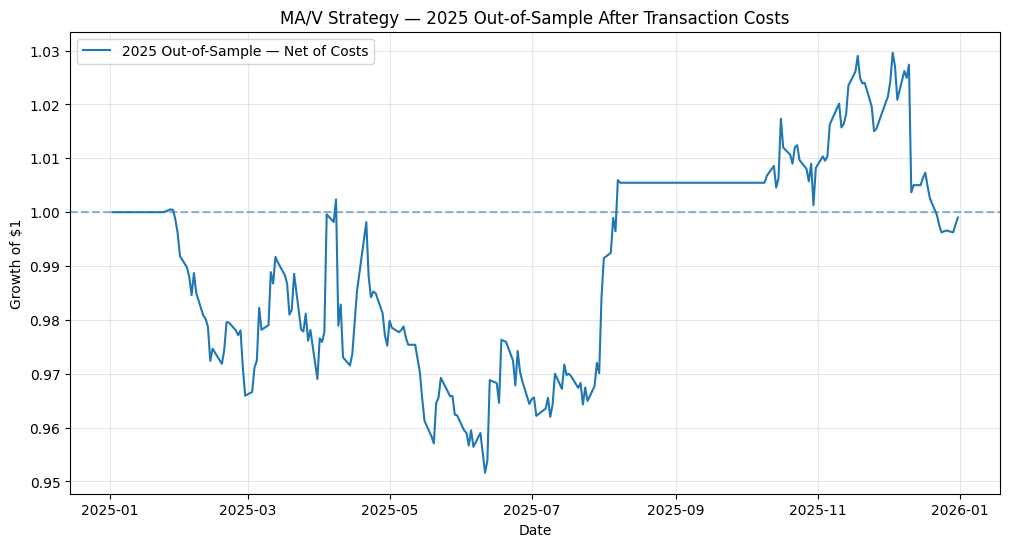

In [45]:
net_portfolio_returns = portfolio_returns - transaction_costs

net_equity = (1 + net_portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(
    net_equity,
    label="2025 Out-of-Sample — Net of Costs"
)

plt.axhline(1, linestyle="--", alpha=0.5)

plt.title("MA/V Strategy — 2025 Out-of-Sample After Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [46]:
net_total_return = net_equity.iloc[-1] - 1

net_volatility = (
    net_portfolio_returns.std() * np.sqrt(252)
)

net_sharpe = (
    net_portfolio_returns.mean() /
    net_portfolio_returns.std()
) * np.sqrt(252)

net_running_max = net_equity.cummax()
net_drawdown = net_equity / net_running_max - 1
net_max_drawdown = net_drawdown.min()

print(f"Net Total Return: {net_total_return:.2%}")
print(f"Net Annualised Volatility: {net_volatility:.2%}")
print(f"Net Sharpe Ratio: {net_sharpe:.2f}")
print(f"Net Maximum Drawdown: {net_max_drawdown:.2%}")

Net Total Return: -0.10%
Net Annualised Volatility: 7.19%
Net Sharpe Ratio: 0.02
Net Maximum Drawdown: -5.07%


In [47]:
# Correct transaction-cost timing
turnover = test_signals.diff().abs()
turnover.iloc[0] = abs(test_signals.iloc[0])

# Signal generated today -> trade executed next day
transaction_costs_corrected = turnover.shift(1).fillna(0) * cost_rate

# Net portfolio returns
net_portfolio_returns = portfolio_returns - transaction_costs_corrected

net_equity = (1 + net_portfolio_returns).cumprod()

print(f"Total transaction costs: {transaction_costs_corrected.sum():.4%}")

Total transaction costs: 0.1500%


In [48]:
net_total_return = net_equity.iloc[-1] - 1
net_volatility = net_portfolio_returns.std() * np.sqrt(252)

net_sharpe = (
    net_portfolio_returns.mean() /
    net_portfolio_returns.std()
) * np.sqrt(252)

net_running_max = net_equity.cummax()
net_drawdown = net_equity / net_running_max - 1
net_max_drawdown = net_drawdown.min()

print(f"Net Total Return: {net_total_return:.2%}")
print(f"Net Annualised Volatility: {net_volatility:.2%}")
print(f"Net Sharpe Ratio: {net_sharpe:.2f}")
print(f"Net Maximum Drawdown: {net_max_drawdown:.2%}")

Net Total Return: -0.10%
Net Annualised Volatility: 7.19%
Net Sharpe Ratio: 0.02
Net Maximum Drawdown: -5.07%


In [50]:
def run_backtest(entry_threshold, exit_threshold):
    signals = pd.Series(0.0, index=z_test.index)
    position = 0

    for date in z_test.index:
        z = z_test.loc[date]

        if position == 0:
            if z < -entry_threshold:
                position = 1
            elif z > entry_threshold:
                position = -1

        elif position == 1:
            if z > -exit_threshold:
                position = 0

        elif position == -1:
            if z < exit_threshold:
                position = 0

        signals.loc[date] = position

    # Portfolio return
    returns = (
        signals.shift(1) *
        (w_ma * ma_test_returns + w_v * v_test_returns)
    ).fillna(0)

    # Transaction costs
    turnover = signals.diff().abs()
    turnover.iloc[0] = abs(signals.iloc[0])

    costs = turnover.shift(1).fillna(0) * cost_rate

    net_returns = returns - costs

    equity = (1 + net_returns).cumprod()

    total_return = equity.iloc[-1] - 1

    sharpe = (
        net_returns.mean() /
        net_returns.std()
    ) * np.sqrt(252) if net_returns.std() != 0 else np.nan

    max_dd = (
        equity / equity.cummax() - 1
    ).min()

    return total_return, sharpe, max_dd

In [51]:
results = []

for entry in [1.5, 2.0, 2.5]:
    for exit_level in [0.0, 0.5, 1.0]:

        total_return, sharpe, max_dd = run_backtest(
            entry,
            exit_level
        )

        results.append({
            "Entry": entry,
            "Exit": exit_level,
            "Return": total_return,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd
        })

robustness = pd.DataFrame(results)

robustness

,Entry,Exit,Return,Sharpe,Max Drawdown
0,1.5,0.0,-0.024684,-0.306623,-0.073830
1,1.5,0.5,-0.023946,-0.296258,-0.073830
2,1.5,1.0,-0.023466,-0.294491,-0.073830
3,2.0,0.0,-0.001756,0.011146,-0.050654
4,2.0,0.5,-0.001001,0.021748,-0.050654
5,2.0,1.0,0.016611,0.282201,-0.050654
6,2.5,0.0,0.020981,0.337047,-0.050654
7,2.5,0.5,0.021753,0.348086,-0.050654
8,2.5,1.0,0.045175,0.733295,-0.050654


# Final Out-of-Sample Results

| Metric | 2025 Result |
|---|---:|
| Net Return | -0.10% |
| Annualised Volatility | 7.19% |
| Sharpe Ratio | 0.02 |
| Maximum Drawdown | -5.07% |
| Transaction Costs | 0.15% |

# Conclusion

This project investigated whether statistically related equity pairs could generate
market-neutral mean-reversion alpha.

A universe of 16 liquid equities was screened, producing 120 candidate pairs.
Visa (V) and Mastercard (MA) were selected for further analysis based on both
their economic similarity and statistical evidence of cointegration.

An OLS hedge ratio was estimated using the 2021–2024 training period, and
z-score-based trading signals were evaluated on the unseen 2025 test period.

The fixed-threshold strategy was evaluated after portfolio normalisation and
transaction costs. The out-of-sample strategy produced approximately a 0 Sharpe
ratio, indicating that the historical relationship did not translate into
persistent trading alpha during 2025.

Robustness testing showed meaningful sensitivity to entry and exit thresholds,
suggesting parameter instability and limited robustness of the simple
mean-reversion specification.

## Key takeaway

The analysis demonstrates that correlation and cointegration alone do not
guarantee a profitable statistical-arbitrage strategy. Out-of-sample validation,
transaction costs, parameter stability and careful backtesting are critical when
evaluating quantitative strategies.